In [1]:
import pandas as pd
import cv2
import numpy as np
import os

In [2]:

imageName = {"circle": [], "triangle": [], "square": []}
basePath = {
        "circle": r"D:\Python\ANN\Datasets\shapes\circles",
        "triangle": r"D:\Python\ANN\Datasets\shapes\triangles",
        "square": r"D:\Python\ANN\Datasets\shapes\squares"
}

#os.listdir(path)
for key in basePath.keys():
    for img in os.listdir(basePath[key]):
        imageName[key].append(img)

imageName

{'circle': ['drawing(1).png',
  'drawing(1).pngaugcircles0.png',
  'drawing(1).pngaugcircles0.pngaugcircles1.png',
  'drawing(10).png',
  'drawing(10).pngaugcircles1.png',
  'drawing(10).pngaugcircles1.pngaugcircles3.png',
  'drawing(10).pngaugcircles2.png',
  'drawing(100).png',
  'drawing(100).pngaugcircles2.png',
  'drawing(100).pngaugcircles2.pngaugcircles5.png',
  'drawing(100).pngaugcircles4.png',
  'drawing(11).png',
  'drawing(11).pngaugcircles3.png',
  'drawing(11).pngaugcircles3.pngaugcircles7.png',
  'drawing(11).pngaugcircles6.png',
  'drawing(12).png',
  'drawing(12).pngaugcircles4.png',
  'drawing(12).pngaugcircles4.pngaugcircles9.png',
  'drawing(12).pngaugcircles8.png',
  'drawing(13).png',
  'drawing(13).pngaugcircles10.png',
  'drawing(13).pngaugcircles5.png',
  'drawing(13).pngaugcircles5.pngaugcircles11.png',
  'drawing(14).png',
  'drawing(14).pngaugcircles12.png',
  'drawing(14).pngaugcircles6.png',
  'drawing(14).pngaugcircles6.pngaugcircles13.png',
  'drawing(15

In [3]:
data = {"label": [], "imageData": []}

for key in imageName.keys():
    for n in imageName[key]:
        path = os.path.join(basePath[key], n)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = np.array(img)
        img = cv2.bitwise_not(img)
        img[img>0] = 1
        img = img.flatten()
        data['label'].append(key)
        data['imageData'].append(img)

data
df = pd.DataFrame(data)
df


,label,imageData
0,circle,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,circle,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,circle,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,circle,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,circle,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...
1192,square,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1193,square,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1194,square,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1195,square,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [4]:
len(df['imageData'])


1197

In [5]:
len(df['label'])


1197

In [6]:
col = [x for x in range(0, len(df['imageData'][0]))]
dat = pd.DataFrame (columns=col)

'''
for i in range(0, len(df['imageData'])):
    dat = dat.append(pd.Series(df['imageData'][i]), ignore_index=True)
Deprecated function
'''

for i in range (0, len(df['imageData'])):
    row = pd.DataFrame([df['imageData'][i]], columns=col)
    dat = pd.concat([dat, row], ignore_index=True)

dat

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1193,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1194,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1195,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping, History

In [8]:
y = np.array(pd.get_dummies(df['label']), np.int64)
x = np.array(dat, np.int64)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [9]:
model = Sequential()
model.add(Dense(2048, input_shape=(x_train.shape[1],), activation='relu'))
model.add(Dense(1024, activation='relu'))
model.add(Dense(512, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.summary()

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
stop = EarlyStopping(monitor='val_accuracy', mode='max', patience=40, restore_best_weights=True)
history = model.fit (x_train, y_train, validation_data=(x_test, y_test), callbacks=[stop], epochs=100, batch_size=20, verbose=1)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2048)              1607680   
                                                                 
 dense_1 (Dense)             (None, 1024)              2098176   
                                                                 
 dense_2 (Dense)             (None, 512)               524800    
                                                                 
 dense_3 (Dense)             (None, 64)                32832     
                                                                 
 dense_4 (Dense)             (None, 3)                 195       
                                                                 
Total params: 4,263,683
Trainable params: 4,263,683
Non-trainable params: 0
_________________________________________________________________
Epoch 1/100
48/48 [===========================

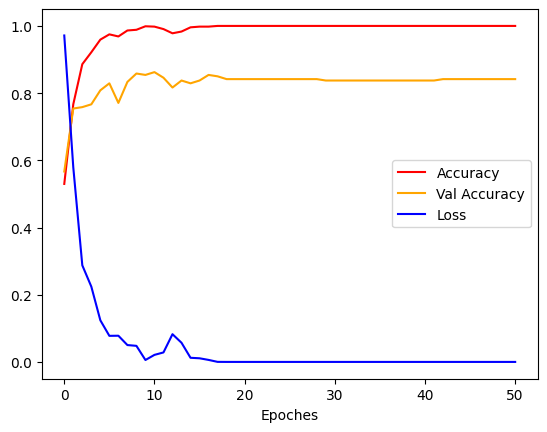

In [13]:
import matplotlib.pyplot as plt

history.history.keys()
his = history.history

accuracy = his['accuracy']
val_accuracy = his['val_accuracy']
loss = his['loss']
val_loss = his['val_loss']

plt.plot(accuracy, color='red', label='Accuracy')
plt.plot(val_accuracy, color='orange', label='Val Accuracy')
plt.plot(loss, color='blue', label='Loss')
plt.xlabel('Epoches')
plt.legend()
plt.show()


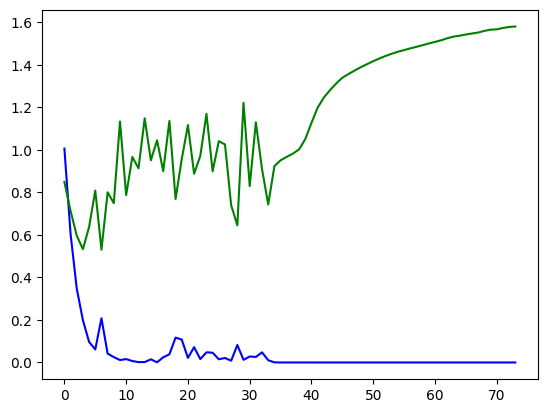

In [75]:
plt.plot(loss, color='blue')
plt.plot (val_loss, color='green')
plt.show()

In [14]:
pred = model.predict(x_test)
y_pred = []

for i in range(0, len(pred)):
    index = np.argmax(pred[i])

    if index == 0:
        y_pred.append('circle')
    if index == 1:
        y_pred.append('square')
    if index == 2:
        y_pred.append('triangle')

y_true = []
for i in range(0, len(y_test)):
    index = np.argmax(y_test[i])

    if index == 0:
        y_true.append('circle')
    if index == 1:
        y_true.append('square')
    if index == 2:
        y_true.append('triangle')



8/8 [==============================] - 1s 24ms/step


In [15]:
from sklearn.metrics import accuracy_score

accuracy_score(y_pred, y_true)

0.8625

In [86]:
len(y_test)

240

Text(50.722222222222214, 0.5, 'True')

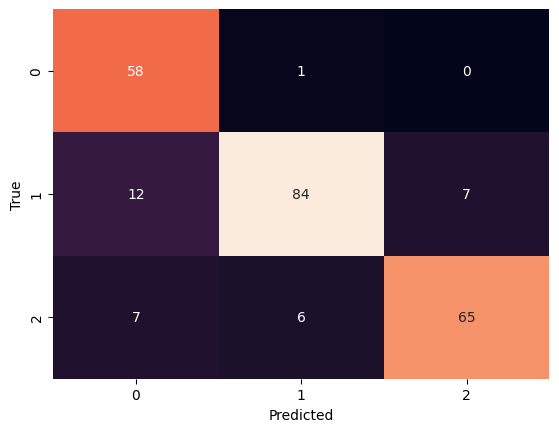

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

con = confusion_matrix (y_pred, y_true)
sns.heatmap(con, annot=True, cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')

In [113]:
model.save("shape_classifier.h5")

In [115]:
model = None

from keras.models import load_model

model = load_model("shape_classifier.h5")

path = r"D:\Python\ANN\Datasets\shapes\Predict\predS.png"
path = os.path.join(path)
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
img = np.array(img)
img = cv2.bitwise_not(img)
img[img>0] = 1
img = img.flatten()

img

singlePred = model.predict(img.reshape(1,784))
singlePred

index = np.argmax(singlePred)

if index == 0:
    nnn = 'circle'
if index == 1:
    nnn = 'square'
if index == 2:
    nnn = 'triangle'

nnn

1/1 [==============================] - 1s 554ms/step


'square'